<a href="https://colab.research.google.com/github/Wunzir/Projects-in-AI-ML/blob/main/hw04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sequence Models**
A Recurrent Neural Network is a neural network that can be used when your data is treated as a sequence, where the order of the data-points matter.

## **Task 2:**

In this task, you will pick a dataset (time-series or any other form of sequential data) and an associated problem that can be solved via sequence models. You must describe why you need sequence models to solve this problem. Include a link to the dataset source. Next, you should pick an RNN framework that you would use to solve this problem (This framework can be in TensorFlow, PyTorch or any other Python Package).

### **Dataset Datasheet**

#### **1. Motivation**
This dataset was created to provide a consolidated historical record of daily weather observations. Based on the underlying filename (`seattle-weather.csv`), we are assuming this data specifically reflects the climate pattern of Seattle, Washington. Our primary motivation for using this dataset is to train a sequence model capable of forecasting future weather based on continuous meteorological measurements

Sequence models are strictly required to solve this problem because weather events are highly time-dependent. Traditional models treat each day's data independently, but sequence models maintain an internal state that captures the chronological context (e.g., a three-day storm) necessary to predict the next day accurately.

While the dataset's subtitle suggests a simple binary classification task (predicting it will rain or not), the detailed description and the actual data allows for more complex and informative multi-class sequence prediction problem using five distinct target classes (drizzle, rain, sun, snow, and fog).
#### **2. Target Definition**
The problem is a **Multi-Class Sequence Classification** task. We will encode the categorical string variable `weather` into a target variable with five distinct classes representing tomorrow's weather:
- **0 (Sun):** Clear or mostly clear skies.
- **1 (Rain):** Steady or heavy rainfall.
- **2 (Drizzle):** Light, scattered percipitation.
- **3 (Snow):** Frozen percipitation.
- **4 (Fog):** Low visibility due to atmospheric moisture.
##### **Cost Analysis**
- **False Negative (High Cost):** The model predicts "Sun" (0) but the actual weather is "Rain" (1) or "Snow" (3). This is a high cost because people, city services, or transporation systems can be caught completely unprepared for wet or freezing conditions, potentially leading to accidents or delays.
- **False Positive (Low Cost):** The model predicts "Rain" (1) or "Snow" (3) but the actual weather is "Sun" (0). This is a low cost because the consequence is simply over-preparation (e.g., carrying an unneeded umbrella or bringing a heavy coat). This outcome is slightly inconvenient and unharmful.
#### **3. Data Source & License/Terms**
- **Source:** [Kaggle (WEATHER PREDICTION)](https://www.kaggle.com/datasets/ananthr1/weather-prediction)
- **Type:** Unknown at this time.
- **Generation Method:** Unknown at this time.
- **License:** CC BY-NC-SA 4.0
- **Privacy:** Unknown at this time.
#### **4. Brief Feature Dictionary**
Below are the primary features used for prediction (after cleaning and removing IDs):
|Feature Name|Data Type|Description|
|---|---|---|
|Date|Time|Date of the weather recorded in `YYYY-MM-DD` format. This will be used strictly to chronologically sort the sequences and will be dropped before model training.|
|Precipitation|Numerical|All forms in which water falls on the land surface and open water bodies such as rain, sleet, snow, hail, or drizzle.|
|temp_max|Numerical|Maximum temperature recorded for that day.|
|temp_min|Numerical|Minimum temperature recorded for that day.|
|wind|Numerical|Wind speed.|
|weather|Categorical|The target output variable containing five classes (drizzle, rain, sun, snow, fog). This will be one-hot encoded.|
#### **5. Known Limitations & Risk**
- **Over-Simplified Features:** The dataset might be too simple. It relies entirely on basic temperature, wind, and precipitation. It misses crucial real-world meteorological factors like barometric pressure, humidity, and cloud cover that heavily dictate weather shifts.
- **Geographic Bias:** Because this is historical data from Seattle, the model will strictly learn the climate patterns of the Pacific Northwest. It will lack the ability to generalize to other regions, meaning it would be highly unreliable for predicting a sudden snowstorm in Troy, for example.
- **Class Imbalance:** The data is heavily skewed toward "rain" and "sun." The model might struggle to learn the patterns for rare events like "snow" or "fog," meaning severe but uncommon weather days could easily go unpredicted.
#### **6. Leakage-Risk Notes**
- **Temporal Leakage:** We cannot use a standard random train/test split. Randomly selecting rows would leak "future" weather patterns into the training set. We must split the data chronologically (e.g., training on the years -, and testing on 2015).
- **Look-Ahead Bias (Target Shifting):** To predict tomorrow's weather, we must shift our target variable up by one time step. If we accidentally use today's features to predict today's weather, the model will not be predicting the future but will be classifying the present.

In [44]:
# import statements for the necessary libraries
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
# Download latest version
path = kagglehub.dataset_download("ananthr1/weather-prediction")

print("Path to dataset files:", path)
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

100%|██████████| 11.5k/11.5k [00:00<00:00, 7.25MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ananthr1/weather-prediction/versions/1


In [ ]:
df = pd.read_csv(os.path.join(path, csv_files[0]))
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [ ]:
# Data Size
print(df.shape)
# Amount of null values
df.isna().sum()

(1461, 6)


,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


In [ ]:
# General information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [ ]:
# Statistics of the dataset (numeric columns)
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [ ]:
dp_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dp_count}")

Number of duplicate rows: 0


In [ ]:
# statistics of the dataset (categorical and time columns)
df.describe(include=['O'])

# count: amount of non-null row entries in a column
# unique: amount of unique categories
# top: most frequent category
# freq: amount of times the most frequent category appeared

,date,weather
count,1461,1461
unique,1461,5
top,2015-12-31,rain
freq,1,641


In [ ]:
# Is the data imbalanced?
results = df['weather'].value_counts(normalize=True)
print(results)

weather
rain       0.438741
sun        0.438056
fog        0.069131
drizzle    0.036277
snow       0.017796
Name: proportion, dtype: float64


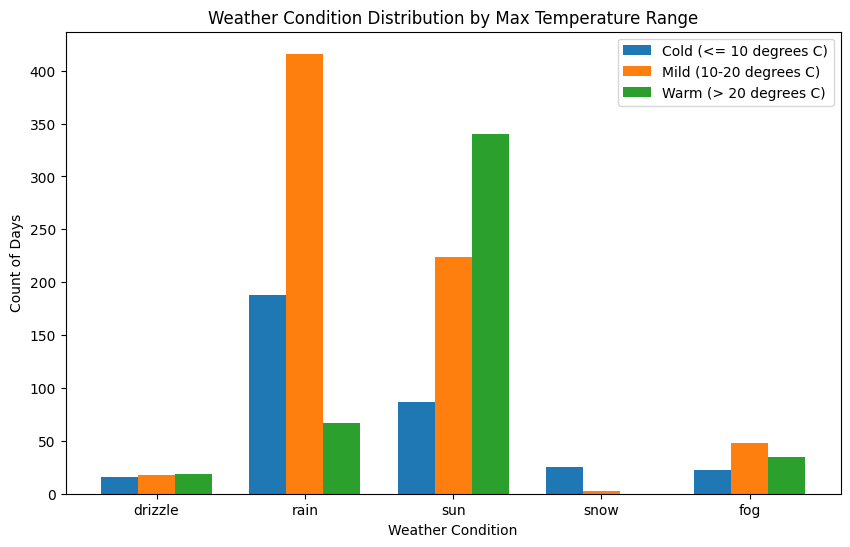

In [ ]:
# Data Visualization
# 1. Define the unique weather categories for the X-axis
labels = df['weather'].unique()

# 2. Define new temperature Groups based on the maximum temperature
# Group 1: Cold (temp_max <= 10.0 degrees celsius)
cold_mask = df["temp_max"] <= 10.0
cold_count = df[cold_mask]["weather"].value_counts().reindex(labels, fill_value=0)
# Group 2: Mild (10.0 degrees celsius < temp_max < 20.0 degrees celsius)
mild_mask = df["temp_max"].between(10.0, 20.0)
mild_count = df[mild_mask]["weather"].value_counts().reindex(labels, fill_value=0)
# Group 3: Warm/Hot (temp_max > 20.0 degrees celsius)
warm_mask = df["temp_max"] > 20
warm_count = df[warm_mask]["weather"].value_counts().reindex(labels, fill_value=0)

# 3. Plotting
x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
# Shift the bars so they group neatly side-by-side
rects1 = ax.bar(x - width, cold_count, width, label='Cold (<= 10 degrees C)')
rects2 = ax.bar(x, mild_count, width, label='Mild (10-20 degrees C)')
rects3 = ax.bar(x + width, warm_count, width, label='Warm (> 20 degrees C)')
# Labels and titles
ax.set_ylabel("Count of Days")
ax.set_xlabel("Weather Condition")
ax.set_title("Weather Condition Distribution by Max Temperature Range")
ax.legend()

# 4. Clean up x-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(labels)

# 5. Show the plot
plt.show()

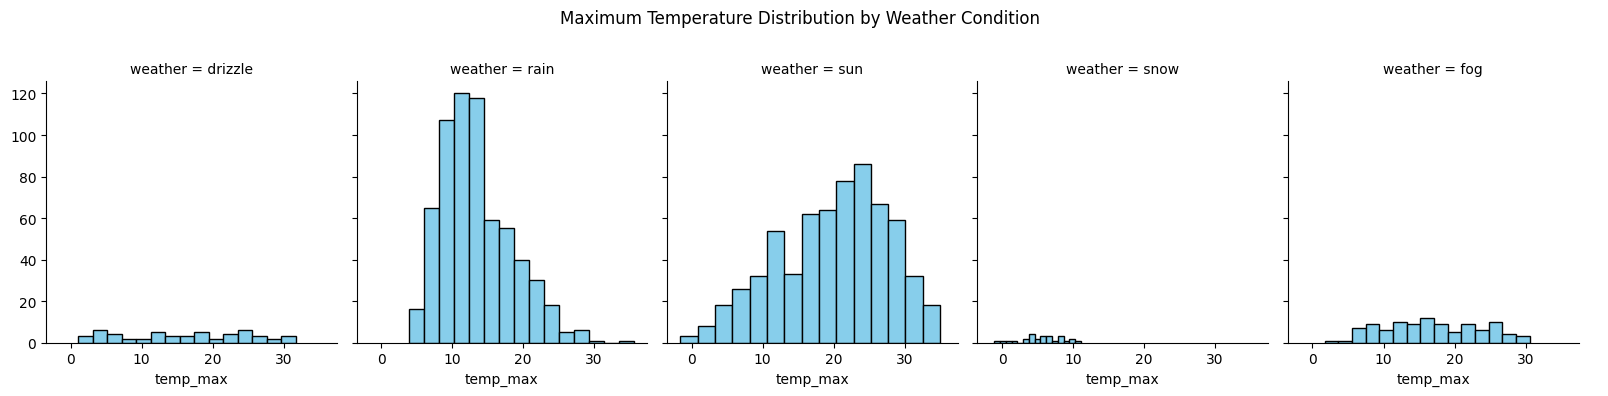

Class counts for encoded target:
weather_class
1    641
0    640
4    101
2     53
3     26
Name: count, dtype: int64


In [ ]:
# Creating Classification Columns
# 1. Create the classification column (label encoding)
# We map the categorical strings to integer classes for the neural network
weatherMapping = {"sun": 0, "rain": 1, "drizzle": 2, "snow": 3, "fog": 4}
# Create a new column with integer targets
df["weather_class"] = df["weather"].map(weatherMapping)

# 2. Visualization
# We map the maximum temperature to see the temperature distribution across
# different weather conditions. Since our dataset is pretty small, we don't need
# to slice it. We can use the whole thing
g = sns.FacetGrid(df, col="weather", height=4, aspect=0.8)
g.map(plt.hist, "temp_max", bins=15, color="skyblue", edgecolor="black")
g.add_legend()
# Adding a title and adjusting the layout so it doesn't overlap
plt.subplots_adjust(top=0.8)
g.fig.suptitle("Maximum Temperature Distribution by Weather Condition")
plt.show()

# 3. Optional: Check the balance of our new encoded column
print("Class counts for encoded target:")
print(df['weather_class'].value_counts())

<Axes: >

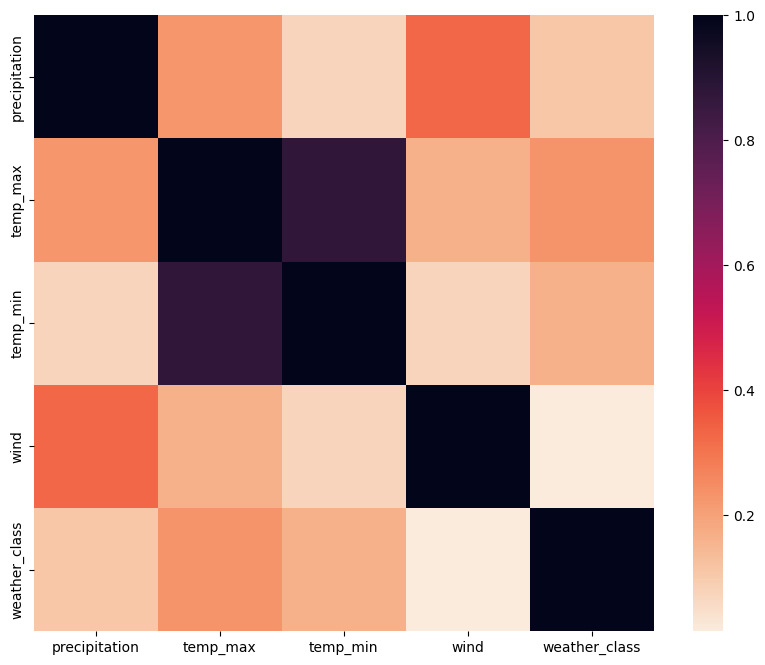

In [30]:
# Heatmap plot
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True).abs(), annot=False, cmap="rocket_r", ax=ax)

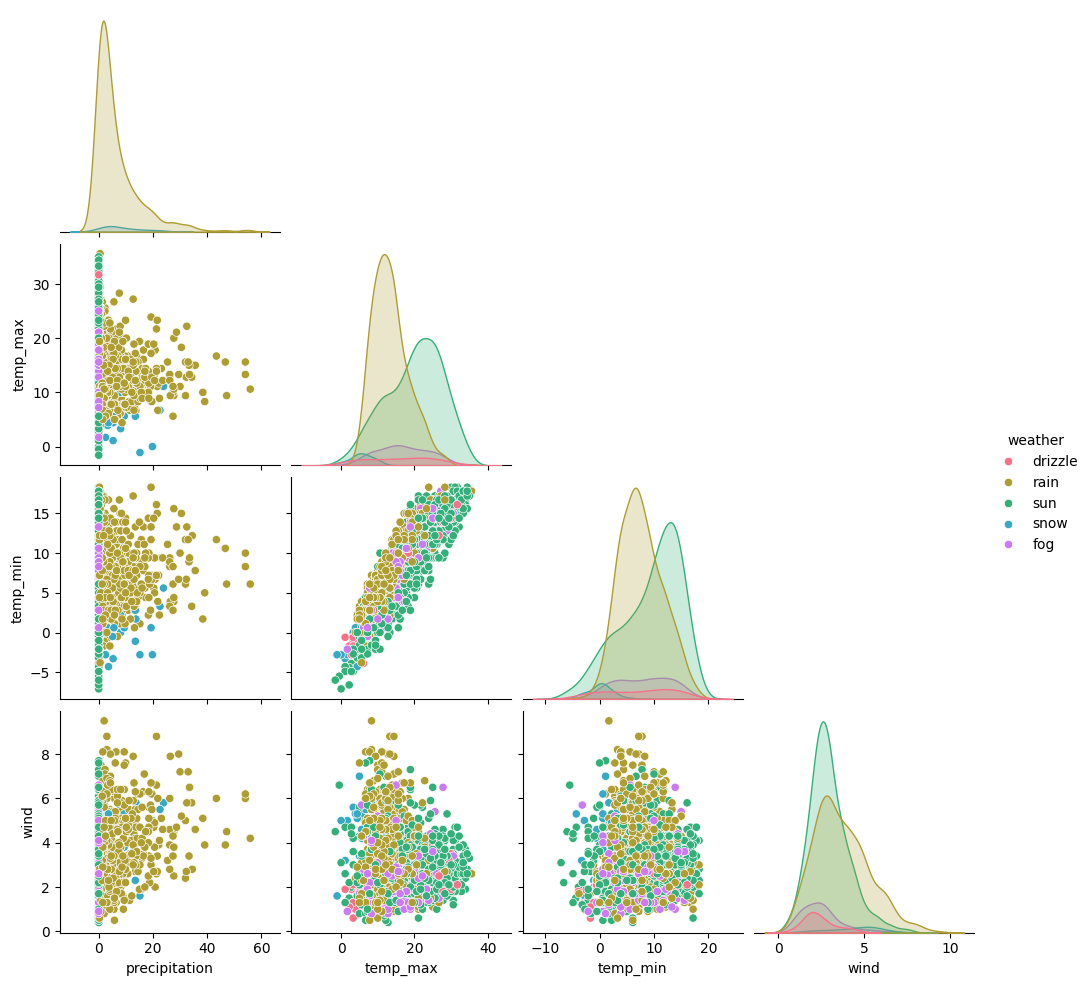

In [32]:
# Selecting the features we want to visualize
features = ["precipitation", "temp_max", "temp_min", "wind", "weather"]

# Creating the pairplot
# diag_kind='kde' creates the smooth density curves on the diagonal
# corner=True removes the redundant upper triangle of the matrix
sns.pairplot(df[features], diag_kind="kde", corner=True, hue="weather", palette="husl")
plt.show()


In [40]:
# Feature correlation with target variable
df.corr(numeric_only=True)["weather_class"].sort_values(ascending=False)

,weather_class
weather_class,1.000000
precipitation,0.110049
wind,-0.014906
temp_min,-0.161623
temp_max,-0.234132


In [41]:
# Data cleanup
# 1. Ensuring Chronological order. We must ensure data is sorted by time before
#    we drop the date column
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date").reset_index(drop=True)

# 2. Drop columns we decide to exclude
# We drop the date column because neural networks only take numerical matrices.
# We also drop the weather column since we already created the `weather_class`
# column.
df = df.drop(columns=["date", "weather"], axis=1, errors="ignore")

# 3. Convert everything to floats
# This ensures all integers are converted to floats which will be useful for the
# underlying matrix multiplication in neural networks
df = df.astype(float)

print("Final Data Shape: ", df.shape)
df.head()

Final Data Shape:  (1461, 5)


,precipitation,temp_max,temp_min,wind,weather_class
0,0.0,12.8,5.0,4.7,2.0
1,10.9,10.6,2.8,4.5,1.0
2,0.8,11.7,7.2,2.3,1.0
3,20.3,12.2,5.6,4.7,1.0
4,1.3,8.9,2.8,6.1,1.0


In [43]:
# Data Normalization
# 1. List of columns to normalize
cols_to_norm = ["precipitation", "temp_max", "temp_min", "wind"]

# 2. Initializing the scalar and applying it
scaler = StandardScaler()
# Fit computes the mean and std, transform applies the z-score formula
df[cols_to_norm] = scaler.fit_transform(df[cols_to_norm])

# 3. Verification
# The mean should practically be 0 or really close to it. The std should be
# exactly 1
print("Standardization check:")
print(df[cols_to_norm].describe().loc[["mean", "std"]])

Standardization check:
      precipitation      temp_max  temp_min          wind
mean   2.674870e-17  9.726800e-18  0.000000 -8.754120e-17
std    1.000342e+00  1.000342e+00  1.000342  1.000342e+00


In [45]:
from re import X
# Time-Series Windowing
# 1. Define the sliding window function
def create_sequences(features, targets, seq_length):
  X = []
  y = []
  # Stop before we run out of days to predict
  for i in range(len(features) - seq_length):
    # Extract a window of `seq_length` days
    X.append(features[i:i+seq_length])
    # The target is the weather code of the day IMMEDIATELY FOLLOWING the window
    y.append(targets[i+seq_length])
  return np.array(X), np.array(y)

# 2. Extract raw numpy arrays from the dataframe
# We only take the scaled continuous features for X, and the integer codes for y
feature_cols = ["precipitation", "temp_max", "temp_min", "wind"]
feature_arrays = df[feature_cols].values
targets_array = df["weather_class"].values
# Set our lookback window to 7 days (1 week)
SEQ_LENGTH = 7
X_all, y_all = create_sequences(feature_arrays, targets_array, SEQ_LENGTH)

# 3. Chronological Train/Val/Test split (70/15/15)
train_idx = int(len(X_all) * 0.7)
val_idx = int(len(X_all) * 0.85)
X_train, y_train = X_all[:train_idx], y_all[:train_idx]
X_val, y_val = X_all[train_idx:val_idx], y_all[train_idx:val_idx]
X_test, y_test = X_all[val_idx:], y_all[val_idx:]

# 4. Convert to PyTorch tensors
# X must be of type float32 for PyTorch weights
# y mus be of type long for the loss function
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f"Training X Shape: {X_train_t.shape}") # Should be (Samples, 7, 4)
print(f"Training y Shape: {y_train_t.shape}")

Training X Shape: torch.Size([1017, 7, 4])
Training y Shape: torch.Size([1017])


### **Task 2.1**
Implement your RNN either using an existing framework OR you can implement your own RNN cell structure. In either case, describe the structure of your RNN and the activation functions you are using for each time step and in the output layer. Define a metric you will use to measure the performance of your mode (NOTE: Performance should be measured both for the validation set and the test set)

In [48]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score

class RNN(nn.Module):
  """
  A simple RNN model for sequence classification.
  """
  def __init__(self, input_size, hidden_size, num_layers, num_classes):
    """
    Initializes the RNN model. Parameters include:
    - input_size: The number of expected features in the input
    - hidden_size: The number of features in the hidden state h
    - num_layers: Number of recurrent layers. E.g., setting num_layers=2 would
                  mean stacking two RNNs together
    - num_classes: The number of output classes
    """
    super(RNN, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers

    # The RNN layer
    # batch_first=True tells PyTorch that our data is formatted as (Batch,
    # Sequence, Features). The default activation is tanh activation
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)

    # The output layer
    self.fc = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    """
    Forward pass of the RNN. It
    """
    # 1. Initialize the hidden state with zeroes
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
    # 2. Forward pass to through the RNN
    out, hn = self.rnn(x, h0)
    # 3. Extract the output from the very last time step
    out = out[:, -1, :]
    # 4. Pass the final time step's output through the fully connected layer
    out = self.fc(out)
    return out

In [47]:
# Instantiating the model
INPUT_SIZE = 4    # Our 4 features: precipitation, temp_max, temp_min, wind
HIDDEN_SIZE = 64  # The size of the RNN's internal memory (tuneable)
NUM_LAYERS = 1    # A basic 1-layer RNN
NUM_CLASSES = 5   # Sun, Rain, Drizzle, Snow, Fog

model = RNN(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES)
print(model)

RNN(
  (rnn): RNN(4, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)


The primary metric used to evaluate the model on both the validation and test sets is the Macro F1-Score, supplemented by overall Accuracy. The Macro F1-Score calculates the harmonic mean of precision and recall for each weather condition independently and then averages them. This ensures the model's performance on minority classes (like snow and fog) is weighted equally to majority classes (like sun and rain).

In [50]:
# 1. Create DataLoaders to feed the data in batches
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. Define loss function and Optimizer
# CrossEntropyLoss() automatically applies Softmax to our output layer
criterion = torch.nn.CrossEntropyLoss()
# Adam optimizer updates the weights based on the calculated gradients
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Lists to store the loss for visualization
train_losses = []
val_losses = []

# 3. Training loop
EPOCHS = 50
for epoch in range(EPOCHS):
  model.train() # Setting model to training mode
  epoch_train_loss = 0
  for X_batch, y_batch in train_loader:
    # A. Zero the gradients
    optimizer.zero_grad()
    # B. Forward pass
    predictions = model(X_batch)
    # C. Calculate loss
    loss = criterion(predictions, y_batch)
    # D. Backward pass
    loss.backward()
    # 5. Update weights
    optimizer.step()
    epoch_train_loss += loss.item()
  # Calculating the average training loss for this epoch
  avg_train_loss = epoch_train_loss / len(train_loader)
  train_losses.append(avg_train_loss)

  # 4. The validation pass
  model.eval() # Setting the model to evaluation mode
  epoch_val_loss = 0
  all_val_preds = []
  all_val_targets = []
  # Disabling gradient calculation for validation
  with torch.no_grad():
    for X_batch, y_batch in val_loader:
      val_preds = model(X_batch)
      val_loss = criterion(val_preds, y_batch)
      epoch_val_loss += val_loss.item()
      # Converting raw logits to predicted class index (0-4)
      _, predicted_class = torch.max(val_preds, 1)
      all_val_preds.extend(predicted_class.numpy())
      all_val_targets.extend(y_batch.numpy())
  avg_val_loss = epoch_val_loss / len(val_loader)
  val_losses.append(avg_val_loss)
  # Calculating F1-score and accuracy
  val_f1 = f1_score(all_val_targets, all_val_preds, average='macro')
  val_acc = accuracy_score(all_val_targets, all_val_preds)
  # Printing progress every 10 epochs
  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}")

Epoch 10/50 | Train Loss: 0.9129 | Val Loss: 1.1282 | Val F1: 0.2866 | Val Acc: 0.5642
Epoch 20/50 | Train Loss: 0.8692 | Val Loss: 1.0798 | Val F1: 0.3381 | Val Acc: 0.6284
Epoch 30/50 | Train Loss: 0.8504 | Val Loss: 1.0777 | Val F1: 0.3326 | Val Acc: 0.6239
Epoch 40/50 | Train Loss: 0.8217 | Val Loss: 1.0748 | Val F1: 0.2425 | Val Acc: 0.5780
Epoch 50/50 | Train Loss: 0.7920 | Val Loss: 1.0887 | Val F1: 0.2508 | Val Acc: 0.5963


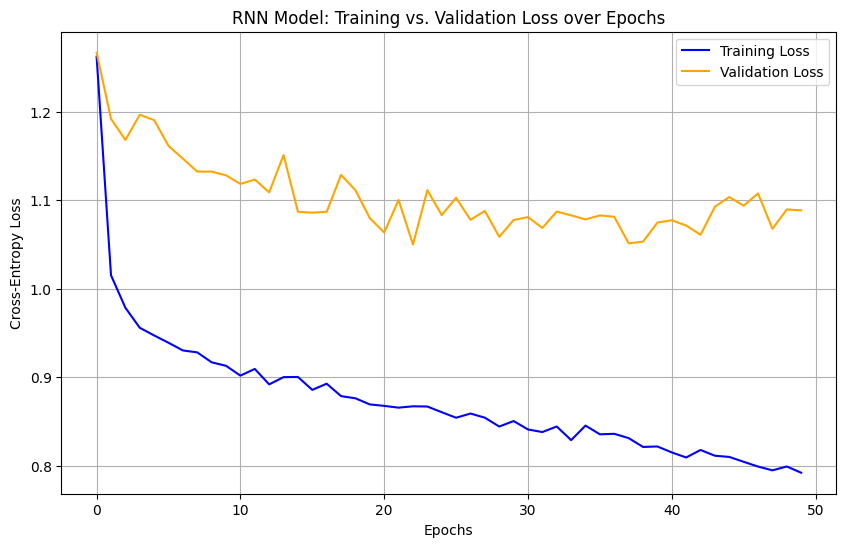

In [51]:
# The overall performance visualization
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title('RNN Model: Training vs. Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [52]:
# 1. Set the model to evaluation mode (freezes weights and dropouts if we had any)
model.eval()

# 2. Disable gradient tracking to save memory and speed up computation
with torch.no_grad():
    # Forward pass the test data
    test_preds = model(X_test_t)

    # Convert the raw output logits into final class predictions (0-4)
    _, test_predicted_classes = torch.max(test_preds, 1)

    # Calculate our required metrics using sklearn
    test_f1 = f1_score(y_test_t.numpy(), test_predicted_classes.numpy(), average='macro', zero_division=0)
    test_acc = accuracy_score(y_test_t.numpy(), test_predicted_classes.numpy())

# 3. Print the final results
print("=== Final Test Set Performance ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score (Macro): {test_f1:.4f}")

=== Final Test Set Performance ===
Test Accuracy: 0.6530
Test F1-Score (Macro): 0.2792


### **Task 2.2**
Update your network from part 1 with first an LSTM and then a GRU based cell structure (You can treat both as 2 separate implementations). Re-do the training and performance evaluation. What are the major differences you notice? Why do you think those differences exist between the 3 implementations (basic RNN, LSTM and GRU)?


In [57]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # The LSTM Layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Initialize BOTH hidden state (h0) and cell state (c0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward pass through the LSTM
        # out shape: (batch_size, seq_length, hidden_size)
        out, _ = self.lstm(x, (h0, c0))

        # Extract the output from the VERY LAST time step (day 7)
        out = out[:, -1, :]

        # Pass through fully connected layer
        out = self.fc(out)
        return out

In [58]:
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # The GRU Layer
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # Initialize hidden state (h0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward pass through the GRU
        out, _ = self.gru(x, h0)

        # Extract the output from the VERY LAST time step
        out = out[:, -1, :]

        out = self.fc(out)
        return out


========== Training LSTM Model ==========


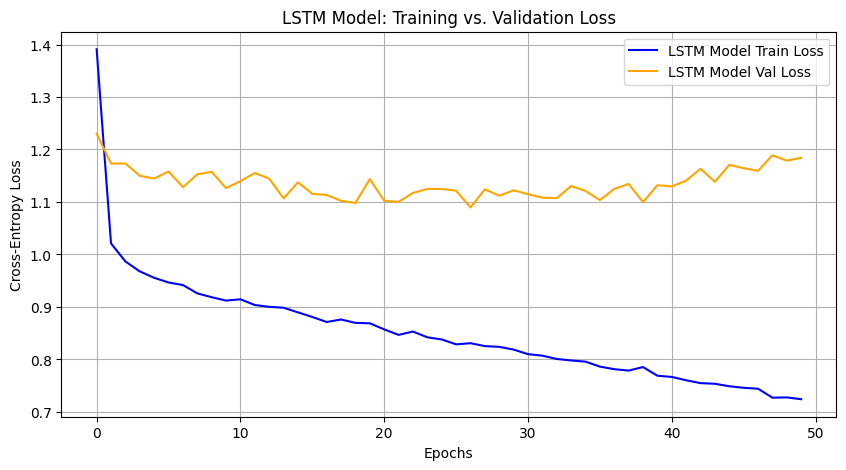

--- LSTM Model Final Test Results ---
Accuracy: 0.6164
F1-Score (Macro): 0.2659


========== Training GRU Model ==========


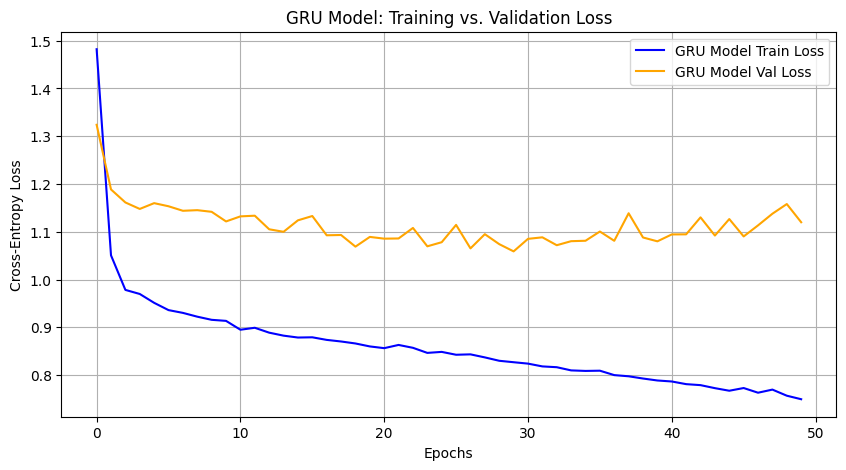

--- GRU Model Final Test Results ---
Accuracy: 0.6438
F1-Score (Macro): 0.2740



GRU(
  (gru): GRU(4, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=5, bias=True)
)

In [61]:
def train_evaluate_visualize(model, model_name, epochs=50):
    print(f"\n========== Training {model_name} ==========")
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    # 1. The Training & Validation Loop
    for epoch in range(epochs):
        # Training Phase
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Phase (Tracking loss for the plot)
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                val_preds = model(batch_X)
                v_loss = criterion(val_preds, batch_y)
                epoch_val_loss += v_loss.item()

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

    # 2. The Overall Performance Visualization
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label=f'{model_name} Train Loss', color='blue')
    plt.plot(val_losses, label=f'{model_name} Val Loss', color='orange')
    plt.title(f'{model_name}: Training vs. Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. Final Evaluation on the Unseen Test Set
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            preds = model(batch_X)
            _, predicted_classes = torch.max(preds, 1)
            all_preds.extend(predicted_classes.numpy())
            all_targets.extend(batch_y.numpy())

    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_targets, all_preds)

    print(f"--- {model_name} Final Test Results ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score (Macro): {f1:.4f}\n")

    return model

# Instantiate fresh models
lstm_model = LSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES)
gru_model = GRU(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES)

# Run the function for both!
train_evaluate_visualize(lstm_model, "LSTM Model")
train_evaluate_visualize(gru_model, "GRU Model")

#### **Model Comparison Summary**
##### **The Results**
- Basic RNN (Best): Accuracy: 65.30% | F1-Score: 0.2792
- GRU (Middle): Accuracy: 64.38% | F1-Score: 0.2740
- LSTM (Worst): Accuracy: 61.64% | F1-Score: 0.2659

##### **Major Differences Noticed**

- **Simplicity Won:** The basic RNN unexpectedly outperformed the more advanced LSTM and GRU architectures.
- **Class Imbalance Impact:** All three models produced low F1-scores (~0.27), indicating they all struggled to predict the rare minority classes (Snow, Fog) and likely defaulted to majority classes (Sun, Rain).

##### **Why These Differences Exist**

- **Overfitting from Complexity:** LSTMs and GRUs contain complex internal gates, meaning they have significantly more trainable parameters. On a small, simple dataset (4 features, ~1,000 sequences), they likely memorized training noise (overfitting), while the simpler RNN generalized better to the unseen test set.

- **Short-Term Context Preference:** The RNN's main weakness, the vanishing gradient problem (forgetting older data), actually worked as an advantage. Tomorrow's weather is usually dictated by the immediate past (e.g., yesterday's temperature). The RNN naturally focused on this recent data, while the LSTM may have been distracted by trying to retain irrelevant data from the beginning of the 7-day window.

### **Task 2.3**
Can you use the traditional feed-forward network to solve the same problem. Why or why not? (Hint: Can time series data be converted to usual features that can be used as input to a feed-forward network?)

#### **Can it be used?**
Yes, a traditional feed-forward network can solve the same problem.
#### **How to convert the data**
**Flattening:** Time series data can be converted to usual features by flattening the multi-day window into a single 1D array of independent variables. For example, 7 days of 4 features become 28 distinct input nodes.

**Rolling Statistics:** The sequence can also be collapsed into standard features by calculating summary metrics, such as a 7-day temperature average or weekly total precipitation.

#### **Why or Why Not?**
**Why it works:** It handles short time windows effectively by treating recent historical data points as separate, independent features.

**Why it is limited:** Feed-forward networks lack an internal memory loop and cannot inherently understand chronological order. Furthermore, expanding the time window (e.g., looking back 30 days) creates a massively bloated input layer, making the model highly susceptible to overfitting.

## **Task 3:**

### **Task 3.1: Implementing Word Embeddings**
- Use a pre-trained word embedding model (Word2Vec, GloVe, FastText, or BERT embeddings).
- Provide a comparative discussion on why you chose this embedding over others.
- Load embeddings efficiently (either from pre-trained vectors or using an NLP library like Gensim, SpaCy, or Hugging Face).
- Allow dynamic user input of two words and output their respective embeddings.
- Handle cases where a word is out of vocabulary (OOV) and suggest ways to approximate its embedding.

#### **Comparative Discussion for BERT Selection**
- **Contextual vs. Static:** Older models like Word2Vec and GloVe are static. The word "bank" gets the exact same mathematical vector whether you say "river bank" or "bank account." BERT is contextual. It reads the entire sentence forward and backward to assign a vector based on the word's specific meaning in that exact sentence.

- **The OOV Solution:** GloVe throws an error if it has never seen a word before. BERT uses a technique called WordPiece Tokenization. Instead of storing millions of whole words, it stores around 30,000 common words and sub-words. If it encounters a bizarre, OOV word, it mathematically chops it up into smaller, recognizable pieces (e.g., "playing" becomes "play" + "##ing").

In [69]:
from transformers import BertTokenizer, BertModel
import torch

# 1. Efficiently Load Pre-trained BERT via Hugging Face
print("Loading BERT tokenizer and model... (This downloads the weights once)")
# We use 'bert-base-uncased' (all lowercase, 110 million parameters)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
print("BERT loaded successfully!\n")

# 2. Dynamic Word Fetcher and OOV Handler
def fetch_bert_embeddings(word1, word2):
    print(f"=== Fetching BERT Embeddings ===\n")

    for word in [word1, word2]:
        word = word.lower().strip()

        # Tokenize the word to see how BERT handles it
        tokens = tokenizer.tokenize(word)
        print(f"Word: '{word}'")
        print(f"Tokens (How BERT sees it): {tokens}")

        # OOV Handling Check: If BERT chopped the word into pieces
        # (indicated by '##'), it was an OOV word!
        if len(tokens) > 1:
            print(f"NOTICE...: '{word}' was Out-Of-Vocabulary (OOV) for BERT's base dictionary.")
            print("   Approximation Strategy: BERT automatically used WordPiece tokenization to break it into subwords.")
        else:
            print(f"HOORAY!: '{word}' is in the base vocabulary.")

        # Convert to PyTorch tensors
        # add_special_tokens=True adds [CLS] at the start and [SEP] at the end
        input_ids = torch.tensor([tokenizer.encode(word, add_special_tokens=True)])

        # Pass through the model to get the embeddings
        with torch.no_grad(): # Disable gradients since we are just extracting features
            outputs = model(input_ids)
            # outputs.last_hidden_state shape: (Batch Size, Sequence Length,
            #                                   Hidden Size)
            # Hidden Size for BERT-base is 768 dimensions.

            # Approximate the final embedding
            # Since an OOV word might be split into 3 tokens, we take the
            # mathematical mean of those tokens (ignoring the [CLS] and [SEP]
            # tokens at the start and end) to get a single vector.
            word_embedding = torch.mean(outputs.last_hidden_state.squeeze(0)[1:-1], dim=0)

        print(f"   Final Vector shape: {word_embedding.shape}")
        # Print just the first 5 dimensions (out of 768) to keep the output clean
        print(f"   First 5 values: {word_embedding[:5].numpy()}\n")
        print("-" * 40)

# 3. Dynamic User Input
input_word_1 = "university"
# We intentionally use an absurd word to force BERT's OOV WordPiece tokenization
# to trigger
input_word_2 = "supercalifragilistic"

fetch_bert_embeddings(input_word_1, input_word_2)

Loading BERT tokenizer and model... (This downloads the weights once)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully!

=== Fetching BERT Embeddings ===

Word: 'university'
Tokens (How BERT sees it): ['university']
HOORAY!: 'university' is in the base vocabulary.
   Final Vector shape: torch.Size([768])
   First 5 values: [-0.4548135  -0.31053957 -1.1394368  -0.20276664  0.6511709 ]

----------------------------------------
Word: 'supercalifragilistic'
Tokens (How BERT sees it): ['super', '##cal', '##if', '##rag', '##ilis', '##tic']
NOTICE...: 'supercalifragilistic' was Out-Of-Vocabulary (OOV) for BERT's base dictionary.
   Approximation Strategy: BERT automatically used WordPiece tokenization to break it into subwords.
   Final Vector shape: torch.Size([768])
   First 5 values: [-0.1562839  -0.22271721  0.25067917 -0.22114396  0.8028862 ]

----------------------------------------


#### **Approximation Strategy for OOV Words**
One approximation strategy for OOV words in our case could be utilizing BERT's sub-word tokenization and then calculating the mean average of those sub-word vectors to create a single, unified vector for the unknown word

### **Task 3.2: Cosine Similarity Computation**
- Implement a function that computes the cosine similarity between two-word embeddings.
- Explain why cosine similarity is useful in word embedding space.
- Allow batch processing, where users can input multiple word pairs for simultaneous similarity computation.
- Visualization Requirement: Create a 2D or 3D scatter plot (e g., using PCA or t-SNE) to visually show how similar and dissimilar words cluster together in the embedding space.

#### **Why Cosine Similarity is Useful**
If we plotted vectors in a 2D space, the length (magnitude) of a word's vector often correlates with how frequently it appears in the training data or how strongly it is activated in a specific sentence. However, the direction of the vector represents its actual semantic meaning.

If we use standard Euclidean Distance (measuring the distance between two points), a common word and a rare word with the same exact meaning might be mathematically far apart just because of their vector lengths.

Cosine similarity is calculates the cosine of the angle between the two vectors, completely ignoring their length.

$$cos(\theta)=\frac{A \cdot B}{||A|| ||B||}$$
- A score of **1.0** means the angle is $0^{\circ}$ (the words have identical contextual meaning)
- A score of **0.0** means the angle is $90^{\circ}$ (the words are completely unrelated)
- A score of **-1.0** means the angle is $180^{\circ}$ (the words are antonyms).

=== Batch Cosine Similarity Results ===
Similarity(algorithm, software) = 0.6998
Similarity(algorithm, tree) = 0.6362
Similarity(forest, tree) = 0.7221
Similarity(campus, university) = 0.6730
Similarity(university, software) = 0.5618


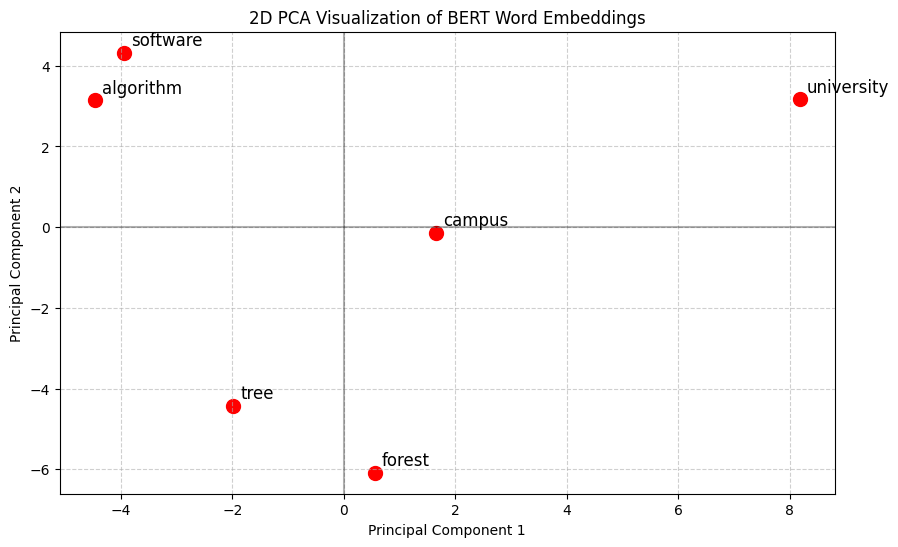

In [70]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Helper Function to Get a Single Vector
def get_bert_vector(word):
    """Retrieves the aggregated BERT embedding for a single word."""
    input_ids = torch.tensor([tokenizer.encode(word.lower().strip(), add_special_tokens=True)])
    with torch.no_grad():
        outputs = model(input_ids)
        # Average the subword tokens, ignoring [CLS] and [SEP]
        vector = torch.mean(outputs.last_hidden_state.squeeze(0)[1:-1], dim=0)
    return vector

# 2. Batch Processing for Cosine Similarity
def batch_cosine_similarity(word_pairs):
    print("=== Batch Cosine Similarity Results ===")

    # Store vectors for PyTorch batch calculation
    tensor_A = []
    tensor_B = []
    unique_words = set()

    for word1, word2 in word_pairs:
        vec1 = get_bert_vector(word1)
        vec2 = get_bert_vector(word2)

        tensor_A.append(vec1)
        tensor_B.append(vec2)
        unique_words.update([word1, word2])

    # Stack lists of 1D tensors into 2D matrices for batch processing
    # Shape becomes (Batch_Size, 768)
    matrix_A = torch.stack(tensor_A)
    matrix_B = torch.stack(tensor_B)

    # Compute similarity for the entire batch at once
    # dim=1 tells PyTorch to calculate across the 768 features
    similarities = F.cosine_similarity(matrix_A, matrix_B, dim=1)

    for i, (word1, word2) in enumerate(word_pairs):
        print(f"Similarity({word1}, {word2}) = {similarities[i].item():.4f}")

    return list(unique_words)

# 3. Dynamic User Input (Batch of Word Pairs)
# We choose distinct clusters (tech vs. nature) to make the scatter plot look great
word_pairs = [
    ("algorithm", "software"),
    ("algorithm", "tree"),
    ("forest", "tree"),
    ("campus", "university"),
    ("university", "software")
]

# Run the batch computation and get the list of unique words back
unique_words = batch_cosine_similarity(word_pairs)

# 4. The Visualization Requirement (PCA Scatter Plot)
# Extract embeddings for all unique words to plot them
plot_vectors = torch.stack([get_bert_vector(w) for w in unique_words]).numpy()

# Initialize PCA to reduce 768 dimensions down to 2
pca = PCA(n_components=2)
xy_coordinates = pca.fit_transform(plot_vectors)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(xy_coordinates[:, 0], xy_coordinates[:, 1], color='red', marker='o', s=100)

# Annotate each dot with its corresponding word
for i, word in enumerate(unique_words):
    plt.annotate(word, (xy_coordinates[i, 0], xy_coordinates[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=12)

plt.title('2D PCA Visualization of BERT Word Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.show()

### **Task 3.3: Designing a Novel Dissimilarity Metric**
- Define a custom dissimilarity score that goes beyond cosine similarity. Possible approaches include:
  - Euclidean distance (How far apart words are in vector space).
  - Word entropy-based dissimilarity (How uncommon two words are relative to each other in corpora).
  - Semantic contrast measure (Using external knowledge bases like WordNet).
- Either design your own metric or cite an existing one from literature (provide a proper reference). Explain why your metric captures novelty/diversity better than cosine similarity alone.
- Allow users to toggle between different similarity dissimilarity measures via function parameters.
- Visualization Requirement:
  - Plot the ranking of words based on their similarity/dissimilarity to a given word (e.g., how words like "cat" rank against "dog," "lion," and "table" using different metrics).
  - Use a heatmap to demonstrate and compare similarity and dissimilarity across multiple (any number of your choice) word pairs.

#### **Euclidean Distance ($L_2$ Norm) as a Dissimilarity Metric**
Instead of measuring the angle, Euclidean distance measures the straight line distance between two points in the 768 dimensional space

$$d(A,B)=\sqrt{\sum_{i=1}^n(A_i-B_i)^2}$$

#### **Why it Captures Novelty Better**
Cosine similarity only measures the angle between two vectors. If two words point in the same exact semanting direction but have vastly different magnitude, cosine similarity scores them as nearly identical. In embedding spaces, magnitude often correlates with word frequency or contextual significance. Euclidean distance factors in both direction and magnitude. This means it can distinguish between a common word and a highly novel, rare word, even if they share similar semantic meaning. This will push them apart in the dissimilarity ranking.

[Link](https://www.sciencedirect.com/topics/computer-science/euclidean-distance)

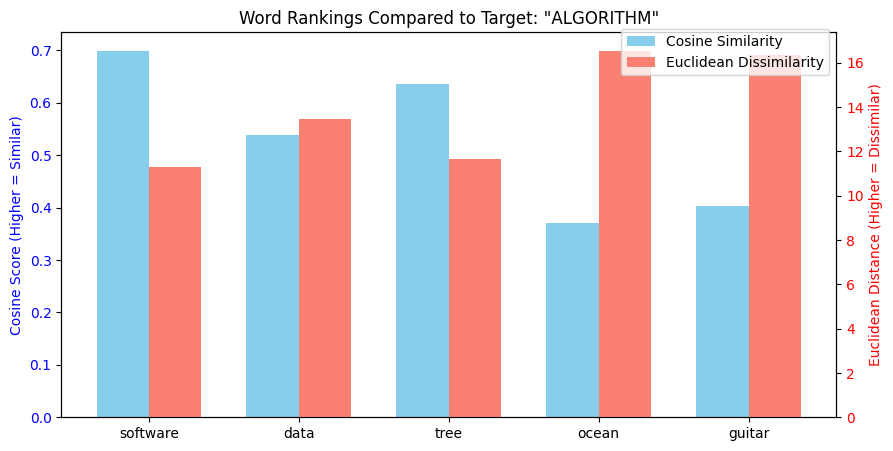

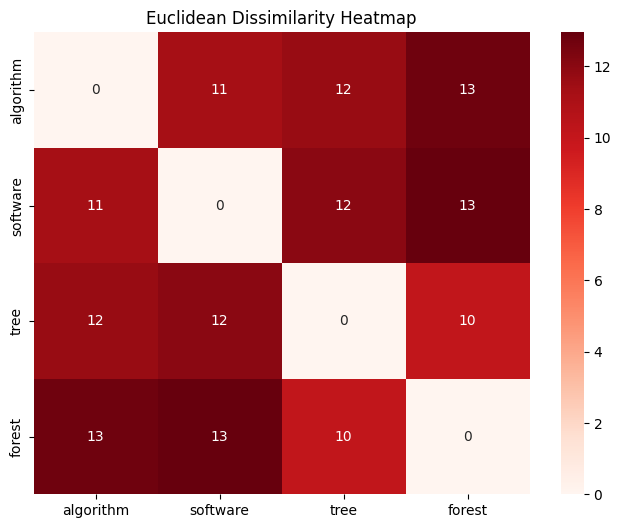

In [71]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. The Toggleable Metric Function
def calculate_relationship(vec1, vec2, metric="cosine"):
    """
    Toggles between Cosine Similarity and Euclidean Dissimilarity.
    """
    if metric == "cosine":
        # Returns Similarity (Higher = more similar)
        return F.cosine_similarity(vec1.unsqueeze(0), vec2.unsqueeze(0)).item()
    elif metric == "euclidean":
        # Returns Dissimilarity (Higher = further apart / more diverse)
        return torch.dist(vec1, vec2, p=2).item()
    else:
        raise ValueError("Metric must be 'cosine' or 'euclidean'")

# 2. Setup Data for Visualization
target_word = "algorithm"
compare_words = ["software", "data", "tree", "ocean", "guitar"]

target_vec = get_bert_vector(target_word)
cosine_scores = []
euclidean_scores = []

for word in compare_words:
    vec = get_bert_vector(word)
    cosine_scores.append(calculate_relationship(target_vec, vec, metric="cosine"))
    euclidean_scores.append(calculate_relationship(target_vec, vec, metric="euclidean"))

# 3. Visualization 1: Ranking Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

x = np.arange(len(compare_words))
width = 0.35

# Plot Cosine (Similarity)
rects1 = ax1.bar(x - width/2, cosine_scores, width, label='Cosine Similarity', color='skyblue')
ax1.set_ylabel('Cosine Score (Higher = Similar)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary y-axis for Euclidean (Dissimilarity) since the scales are different
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, euclidean_scores, width, label='Euclidean Dissimilarity', color='salmon')
ax2.set_ylabel('Euclidean Distance (Higher = Dissimilar)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xticks(x)
ax1.set_xticklabels(compare_words)
ax1.set_title(f'Word Rankings Compared to Target: "{target_word.upper()}"')
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.show()

# 4. Visualization 2: Heatmap of Multiple Word Pairs
# Let's create a matrix of Euclidean distances between several words
heatmap_words = ["algorithm", "software", "tree", "forest"]
distance_matrix = np.zeros((len(heatmap_words), len(heatmap_words)))

for i, w1 in enumerate(heatmap_words):
    for j, w2 in enumerate(heatmap_words):
        v1 = get_bert_vector(w1)
        v2 = get_bert_vector(w2)
        # Calculate Euclidean Dissimilarity
        distance_matrix[i, j] = calculate_relationship(v1, v2, metric="euclidean")

plt.figure(figsize=(8, 6))
sns.heatmap(distance_matrix, annot=True, xticklabels=heatmap_words, yticklabels=heatmap_words, cmap="Reds")
plt.title("Euclidean Dissimilarity Heatmap")
plt.show()